In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

df_pca = pd.read_csv('../data/gaia_pca.csv')

print(df_pca.head())

        PC1       PC2       PC3       PC4
0 -0.596051 -1.400087  0.322000  0.646080
1 -0.773060 -1.361825  0.500167  0.196505
2 -1.744177 -1.482410  0.239986 -0.286465
3  0.922784 -1.124993  0.978373  0.618948
4 -0.828165 -1.341449  0.420942 -0.368206


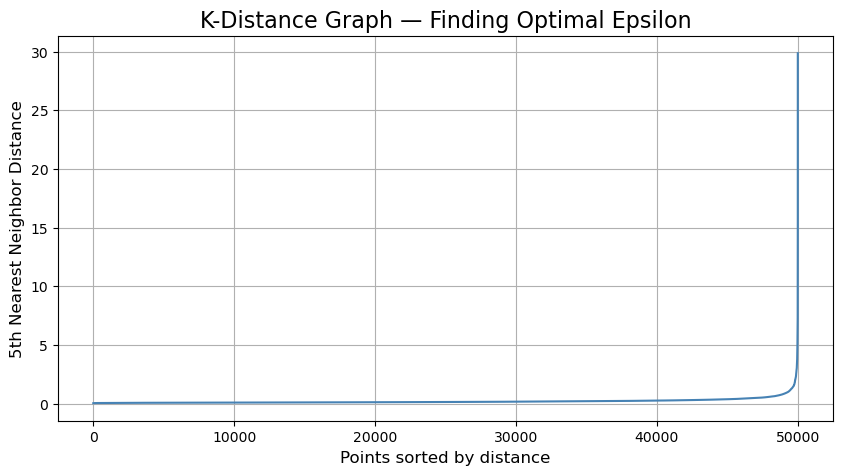

In [2]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(df_pca)
distances, indices = neighbors.kneighbors(df_pca)

distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, color='steelblue')
plt.xlabel('Points sorted by distance', fontsize=12)
plt.ylabel('5th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Graph — Finding Optimal Epsilon', fontsize=16)
plt.grid(True)
plt.savefig('../images/dbscan_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
df_pca['dbscan_cluster'] = dbscan.fit_predict(df_pca[['PC1','PC2','PC3','PC4']])

n_clusters = len(set(df_pca['dbscan_cluster'])) - 1
n_noise = (df_pca['dbscan_cluster'] == -1).sum()

print("Cluster counts:")
print(df_pca['dbscan_cluster'].value_counts())
print(f"\nNumber of clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")

Cluster counts:
dbscan_cluster
 0    38076
 4    11529
-1      367
 5        9
 2        7
 1        6
 3        6
Name: count, dtype: int64

Number of clusters found: 6
Noise points: 367


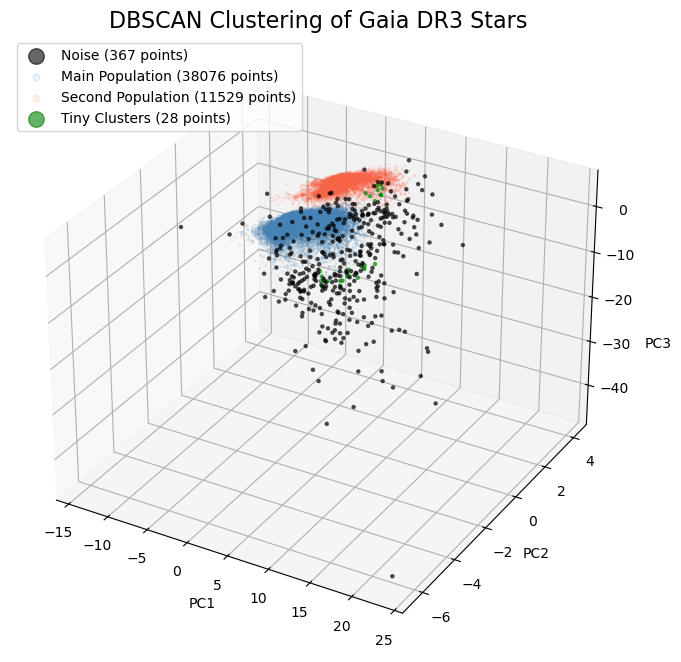

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

noise = df_pca[df_pca['dbscan_cluster'] == -1]
ax.scatter(noise['PC1'], noise['PC2'], noise['PC3'],
           alpha=0.6, s=5, c='black', label=f'Noise ({len(noise)} points)')

main = df_pca[df_pca['dbscan_cluster'] == 0]
ax.scatter(main['PC1'], main['PC2'], main['PC3'],
           alpha=0.1, s=1, c='steelblue', label=f'Main Population ({len(main)} points)')

second = df_pca[df_pca['dbscan_cluster'] == 4]
ax.scatter(second['PC1'], second['PC2'], second['PC3'],
           alpha=0.1, s=1, c='tomato', label=f'Second Population ({len(second)} points)')

tiny = df_pca[~df_pca['dbscan_cluster'].isin([-1, 0, 4])]
ax.scatter(tiny['PC1'], tiny['PC2'], tiny['PC3'],
           alpha=0.6, s=5, c='green', label=f'Tiny Clusters ({len(tiny)} points)')

ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_zlabel('')
ax.text2D(1.03, 0.5, 'PC3', transform=ax.transAxes,
         fontsize=10, va='center')
ax.set_title('DBSCAN Clustering of Gaia DR3 Stars', fontsize=16)
ax.legend(loc='upper left', markerscale=5)

plt.savefig('../images/dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df_pca.to_csv('../data/gaia_dbscan.csv', index=False)

mask = df_pca['dbscan_cluster'] != -1

score = silhouette_score(
    df_pca[['PC1','PC2','PC3','PC4']][mask],
    df_pca['dbscan_cluster'][mask],
    sample_size=10000,
    random_state=42
)
print(f"Silhouette Score: {score:.4f}")
print("DBSCAN results saved!")

Silhouette Score: 0.4060
DBSCAN results saved!
